In [1]:
# Importing all the required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Loading dataset
df = pd.read_csv(r"C:\Amit Dubli\VS code\Assignment 5\ai_project_synthetic_datasets-20260505T155452Z-3-001\ai_project_synthetic_datasets\part_1_neural_network_analysis\customer_churn_nn.csv")

In [3]:
# Preview data
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [4]:
# Cheking number of rows and columns

df.shape

(2000, 17)

In [5]:
# Type of Input features

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

In [6]:
# Target variable description

df["churn"].value_counts()

0    1969
1      31
Name: churn, dtype: int64

In [7]:
# Checking missing value 

df.isnull().sum()

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

In [8]:
#cBasic summary

df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


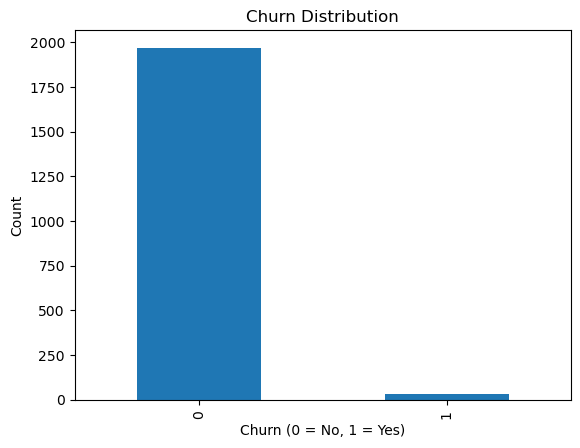

In [9]:
# Target variable distribution

df["churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [10]:
# Seperating features and targets - removing customer_id as it is just for seriel numbering.

X = df.drop(columns=["customer_id", "churn"])
y = df["churn"]

In [11]:
# Handling missing values

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "bool"]).columns

In [12]:
# Filling missing value

# Numerical → use median (robust to outliers)
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Categorical → use most frequent value
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])

In [13]:
# Encoding categorical variables

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [14]:
# Scaling numerical features

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [15]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
# Final checking

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1600, 24)
Testing shape: (400, 24)


In [17]:
# Defining the neural network architecture

model = Sequential()

# Input Layer + Hidden Layer
model.add(Dense(units=16, activation='relu', input_shape=(X_train.shape[1],)))

# Additional Hidden Layer
model.add(Dense(units=8, activation='relu'))

# Output Layer (Binary Classification)
model.add(Dense(units=1, activation='sigmoid'))

In [18]:
# Compiling the model

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [19]:
# Summary

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                400       
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dense_2 (Dense)             (None, 1)                 9         
                                                                 
Total params: 545 (2.13 KB)
Trainable params: 545 (2.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [20]:
# Training the model

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 [==============================] - 2s 11ms/step - loss: 0.5715 - accuracy: 0.7445 - val_loss: 0.4390 - val_accuracy: 0.9250
Epoch 2/20
40/40 [==============================] - 0s 4ms/step - loss: 0.3120 - accuracy: 0.9656 - val_loss: 0.2247 - val_accuracy: 0.9906
Epoch 3/20
40/40 [==============================] - 0s 3ms/step - loss: 0.1757 - accuracy: 0.9812 - val_loss: 0.1230 - val_accuracy: 0.9937
Epoch 4/20
40/40 [==============================] - 0s 3ms/step - loss: 0.1205 - accuracy: 0.9820 - val_loss: 0.0792 - val_accuracy: 0.9937
Epoch 5/20
40/40 [==============================] - 0s 3ms/step - loss: 0.1005 - accuracy: 0.9820 - val_loss: 0.0623 - val_accuracy: 0.9937
Epoch 6/20
40/40 [==============================] - 0s 3ms/step - loss: 0.0921 - accuracy: 0.9820 - val_loss: 0.0554 - val_accuracy: 0.9937
Epoch 7/20
40/40 [==============================] - 0s 3ms/step - loss: 0.0876 - accuracy: 0.9820 - val_loss: 0.0515 - val_accuracy: 0.9937
Epoch 8/20
40/40 [=

In [21]:
# Evaluating on test data

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

13/13 [==============================] - 0s 2ms/step - loss: 0.0606 - accuracy: 0.9850
Test Accuracy: 0.9850000143051147


In [22]:
# Making predictions

y_pred = model.predict(X_test)
print(y_pred[:5])   # See probabilities
y_pred = (y_pred > 0.5).astype(int)
print(y_pred[:5])   # See final predictions (0/1)

13/13 [==============================] - 0s 1ms/step
[[0.0374079 ]
 [0.02565515]
 [0.00071224]
 [0.00088565]
 [0.08293576]]
[[0]
 [0]
 [0]
 [0]
 [0]]


## These customers are very unlikely to churn

In [23]:
# Train the Model

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 [==============================] - 0s 4ms/step - loss: 0.0654 - accuracy: 0.9820 - val_loss: 0.0407 - val_accuracy: 0.9937
Epoch 2/20
40/40 [==============================] - 0s 3ms/step - loss: 0.0645 - accuracy: 0.9820 - val_loss: 0.0406 - val_accuracy: 0.9937
Epoch 3/20
40/40 [==============================] - 0s 3ms/step - loss: 0.0636 - accuracy: 0.9820 - val_loss: 0.0401 - val_accuracy: 0.9937
Epoch 4/20
40/40 [==============================] - 0s 3ms/step - loss: 0.0626 - accuracy: 0.9820 - val_loss: 0.0403 - val_accuracy: 0.9937
Epoch 5/20
40/40 [==============================] - 0s 3ms/step - loss: 0.0616 - accuracy: 0.9820 - val_loss: 0.0396 - val_accuracy: 0.9937
Epoch 6/20
40/40 [==============================] - 0s 3ms/step - loss: 0.0607 - accuracy: 0.9820 - val_loss: 0.0393 - val_accuracy: 0.9937
Epoch 7/20
40/40 [==============================] - 0s 3ms/step - loss: 0.0597 - accuracy: 0.9820 - val_loss: 0.0394 - val_accuracy: 0.9937
Epoch 8/20
40/40 [==

In [24]:
# Training Accuracy & Loss

print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Training Loss:", history.history['loss'][-1])

Final Training Accuracy: 0.985156238079071
Final Training Loss: 0.05001450702548027


In [25]:
# checking validation performance

print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Validation Loss:", history.history['val_loss'][-1])

Validation Accuracy: 0.9937499761581421
Validation Loss: 0.037832219153642654


In [26]:
# Evaluating on Test Data

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

13/13 [==============================] - 0s 1ms/step - loss: 0.0643 - accuracy: 0.9825
Test Accuracy: 0.9825000166893005
Test Loss: 0.0642576813697815


In [27]:
# Predictions for Evaluation

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

13/13 [==============================] - 0s 1ms/step


In [28]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[393   1]
 [  6   0]]


In [29]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



In [30]:
# compairing with test accuracy 

print(test_accuracy)

0.9825000166893005


In [31]:
# keeping the original model as baseline

Dense(16, activation='relu')
Dense(8, activation='relu')
Dense(1, activation='sigmoid')

In [32]:
# Experiment 1: Increasing Model Capacity

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [33]:
# Experiment 2: Changing Learning Rate

from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [34]:
# Experiment 3: Increasing epochs

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
40/40 [==============================] - 1s 5ms/step - loss: 0.2376 - accuracy: 0.9820 - val_loss: 0.1061 - val_accuracy: 0.9937
Epoch 2/50
40/40 [==============================] - 0s 2ms/step - loss: 0.1185 - accuracy: 0.9820 - val_loss: 0.0576 - val_accuracy: 0.9937
Epoch 3/50
40/40 [==============================] - 0s 2ms/step - loss: 0.0976 - accuracy: 0.9820 - val_loss: 0.0475 - val_accuracy: 0.9937
Epoch 4/50
40/40 [==============================] - 0s 2ms/step - loss: 0.0896 - accuracy: 0.9820 - val_loss: 0.0437 - val_accuracy: 0.9937
Epoch 5/50
40/40 [==============================] - 0s 2ms/step - loss: 0.0839 - accuracy: 0.9820 - val_loss: 0.0410 - val_accuracy: 0.9937
Epoch 6/50
40/40 [==============================] - 0s 2ms/step - loss: 0.0799 - accuracy: 0.9820 - val_loss: 0.0401 - val_accuracy: 0.9937
Epoch 7/50
40/40 [==============================] - 0s 2ms/step - loss: 0.0762 - accuracy: 0.9820 - val_loss: 0.0399 - val_accuracy: 0.9937
Epoch 8/50
40/40 [==

In [35]:
# Handling imbalance

class_weight = {0:1, 1:20}

model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight
)

Epoch 1/20
40/40 [==============================] - 0s 3ms/step - loss: 0.1632 - accuracy: 0.9914 - val_loss: 0.1131 - val_accuracy: 0.9438
Epoch 2/20
40/40 [==============================] - 0s 2ms/step - loss: 0.1177 - accuracy: 0.9836 - val_loss: 0.1061 - val_accuracy: 0.9625
Epoch 3/20
40/40 [==============================] - 0s 2ms/step - loss: 0.0777 - accuracy: 0.9891 - val_loss: 0.0776 - val_accuracy: 0.9719
Epoch 4/20
40/40 [==============================] - 0s 2ms/step - loss: 0.0538 - accuracy: 0.9930 - val_loss: 0.0778 - val_accuracy: 0.9688
Epoch 5/20
40/40 [==============================] - 0s 2ms/step - loss: 0.0486 - accuracy: 0.9953 - val_loss: 0.0815 - val_accuracy: 0.9688
Epoch 6/20
40/40 [==============================] - 0s 2ms/step - loss: 0.0410 - accuracy: 0.9953 - val_loss: 0.0678 - val_accuracy: 0.9781
Epoch 7/20
40/40 [==============================] - 0s 2ms/step - loss: 0.0353 - accuracy: 0.9969 - val_loss: 0.0756 - val_accuracy: 0.9688
Epoch 8/20
40/40 [==

In [36]:
print("Final Accuracy:", history.history['accuracy'][-1])
print("Final Loss:", history.history['loss'][-1])

print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Validation Loss:", history.history['val_loss'][-1])

Final Accuracy: 0.9945312738418579
Final Loss: 0.015574032440781593
Validation Accuracy: 0.987500011920929
Validation Loss: 0.049028802663087845


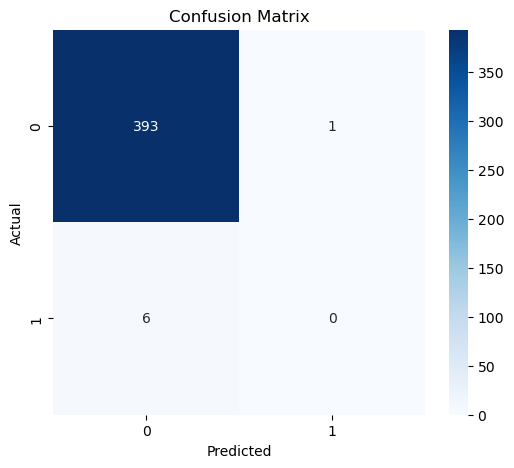

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("evaluation_output.png")
plt.show()

## Summary

The neural network learned that “Most customers do not churn, so predicting 0 always gives high accuracy.”

As the dataset is highly imbalanced so non-churn customers dominate the data and thus model ignored the minority class completely. 

The model is thus not effective for churn prediction and thus business objective is not satisfied.

## What role do weights and biases play in the model?

1. Weights determine how important each input feature is for prediction.
2. Bias helps shift the output up or down, allowing the model to fit the data better even when all inputs are zero.

So collectively Weights learn relationships, and bias adjusts the prediction for better accuracy

## Why is an activation function required?

1. Without an activation function, the neural network becomes just a linear model (like linear regression), no matter how many layers you add.
2. Activation functions (like ReLU, sigmoid) introduce non-linearity, allowing the model to learn complex patterns.

here 
1. ReLU helps learn patterns in hidden layers
2. Sigmoid converts output into a probability (0 to 1) for churn

## What happens when learning rate is too high or too low?

If Learning Rate is Too High
1. Model updates weights too aggressively
2. May overshoot optimal solution
3. Loss may fluctuate or not decrease properly

This results in unstable training

If Learning Rate is Too Low
1. Model learns very slowly
2. Takes too long to converge
3. May get stuck before reaching optimal solution

This results in inefficient or incomplete learning

## Did your model show signs of underfitting or overfitting? Explain.

The model shows neither classic underfitting nor overfitting, but a different issue

Training, validation, and test accuracy are all very high 98% to 99%
But confusion matrix shows:
1. Model predicts only non-churn (0)
2. Fails to detect churn completely